In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import  Dataset, DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", torch.cuda.get_device_name(0))

rng = np.random.default_rng()

Using device: NVIDIA GeForce RTX 2080


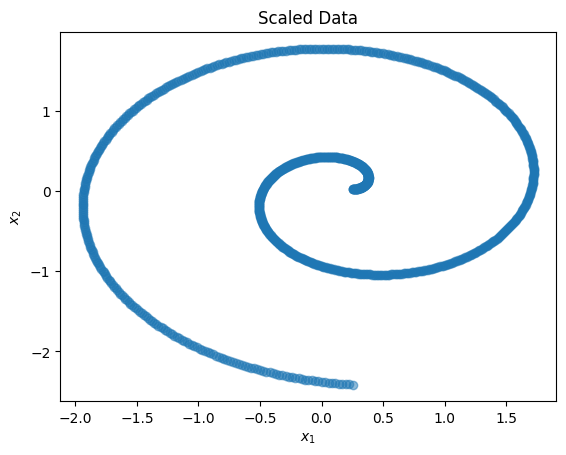

In [2]:
N = 1000

alpha = 0
beta = 5
omega = 1.75

theta = np.linspace(0, 2*np.pi*omega, N)

r = alpha + beta*theta

x1 = r * np.cos(theta)
x2 =  r * np.sin(theta)

X = np.vstack((x1, x2)).T

mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
X = (X - mu) / sigma

plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Scaled Data')
plt.show()
plt.close()

In [3]:
T = 1000

var_decay_min = 0.0001
var_decay_max = 0.02

beta = np.linspace(var_decay_min, var_decay_max, T)
alpha = (1 - beta)

alpha_bar = np.cumprod(alpha)

mean_scale = np.sqrt(alpha_bar)
var_scale = np.sqrt(1-alpha_bar)

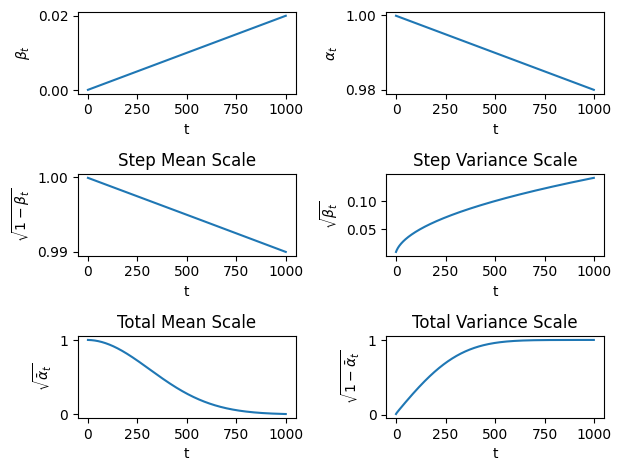

In [4]:
fig, axs = plt.subplots(3, 2)

axs[0, 0].plot(beta)
axs[0, 0].set_ylabel(r'$\beta_t$')
axs[0, 0].set_xlabel('t')

axs[0, 1].plot(1-beta)
axs[0, 1].set_ylabel(r'$ \alpha_t $')
axs[0, 1].set_xlabel('t')

axs[1, 0].plot(np.sqrt(1-beta))
axs[1, 0].set_ylabel(r'$ \sqrt{1-\beta_t} $')
axs[1, 0].set_xlabel('t')
axs[1, 0].set_title('Step Mean Scale')

axs[1, 1].plot(np.sqrt(beta))
axs[1, 1].set_ylabel(r'$ \sqrt{\beta_t} $')
axs[1, 1].set_xlabel('t')
axs[1, 1].set_title('Step Variance Scale')

axs[2, 0].plot(np.sqrt(alpha_bar))
axs[2, 0].set_ylabel(r'$ \sqrt{\bar \alpha_t} $')
axs[2, 0].set_xlabel('t')
axs[2, 0].set_title('Total Mean Scale')

axs[2, 1].plot(np.sqrt(1-alpha_bar))
axs[2, 1].set_ylabel(r'$ \sqrt{1 - \bar \alpha_t} $')
axs[2, 1].set_xlabel('t')
axs[2, 1].set_title('Total Variance Scale')

plt.tight_layout()
plt.show()
plt.close()

In [5]:
def diffuse(x0, t, mean_scale, var_scale):
    return x0 * mean_scale[t-1] + var_scale[t-1]*rng.normal(0, 1, size=x0.shape)

def diffusion_step(x, t, beta):
    return x* np.sqrt(1-beta[t-1]) + np.sqrt(beta[t-1])*rng.normal(0, 1, size=x.shape)

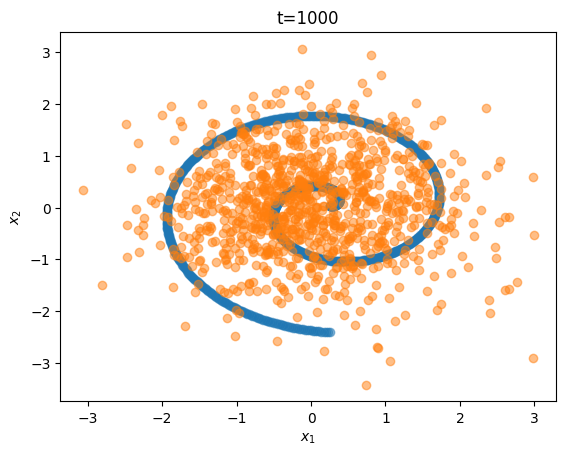

In [6]:
t=T

X_t = diffuse(X, t, mean_scale, var_scale)

plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.scatter(X_t[:, 0], X_t[:, 1], alpha=0.5)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('t='+str(t))
plt.show()
plt.close()

In [ ]:
spacing = 10

fig, ax = plt.subplots()

scat = ax.scatter(X[:, 0], X[:, 1], alpha=0.5)
max_edge = np.ceil(np.max(np.abs(X_t)))+1
ax.set(xlim=[-max_edge, max_edge], ylim=[-max_edge, max_edge])

def update(frame):
    global max_edge
    global X_t
    
    if frame==0:
        X_t = X
        scat.set_offsets(X_t)
    else:
        for i in range(spacing):
            t = ((frame*spacing)-spacing) + i + 1
            X_t = diffusion_step(X_t, t, beta)
        scat.set_offsets(X_t)

    edge = np.ceil(np.max(np.abs(X_t)))+1
    if max_edge < edge:
        max_edge = edge
        ax.set(xlim=[-max_edge, max_edge], ylim=[-max_edge, max_edge])
        
    ax.set_title('t='+ str(frame*spacing))

    return scat

ani = animation.FuncAnimation(fig=fig, func=update, frames=int(T/spacing)+1, interval=30)

plt.close()
HTML(ani.to_jshtml())

In [8]:
class CustomDataset(Dataset):
    def __init__(self, X):
        self.X = X

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x0 = self.X[idx]
        return x0

class DiffusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

model = DiffusionModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [9]:
X_tensor = torch.from_numpy(X).float()
mean_scale_tensor = torch.from_numpy(mean_scale).float()
var_scale_tensor = torch.from_numpy(var_scale).float()

dataset = CustomDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [10]:
def train(model, dataloader, mean_scale_tensor, var_scale_tensor, epochs=2000, save=False, name=""):
    training_loss = []
    
    model = model.to(device)
    mean_scale_tensor = mean_scale_tensor.to(device)
    var_scale_tensor = var_scale_tensor.to(device)
    
    pbar = tqdm(range(epochs), desc="Training")
    for epoch in pbar:
        model.train()
        epoch_loss = 0.0
    
        for X_batch in dataloader:
            X_batch = X_batch.to(device)
    
            batch_size = X_batch.shape[0]
    
            t_batch = torch.randint(low=1, high=T+1, size=(batch_size,), device=device)
    
            epsilon_batch = torch.randn((batch_size, 2), device=device)
    
            X_t_batch = X_batch * mean_scale_tensor[t_batch-1].unsqueeze(-1) + var_scale_tensor[t_batch-1].unsqueeze(-1) * epsilon_batch
    
            t_feature = (t_batch.float() / T).unsqueeze(-1)
            
            X_input = torch.cat([X_t_batch, t_feature], dim=-1)
            
            optimizer.zero_grad()
            
            epsilon_hat = model(X_input)
    
            loss = criterion(epsilon_hat, epsilon_batch)
    
            loss.backward()
            optimizer.step()
    
            epoch_loss += loss.item()
    
        training_loss.append(epoch_loss)
        pbar.set_postfix({"loss": f"{epoch_loss:.4f}"})

    if save:
        torch.save(model.state_dict(), "./Models/" + name + ".pth")

    return model, training_loss

Training:   0%|          | 0/2000 [00:00<?, ?it/s]

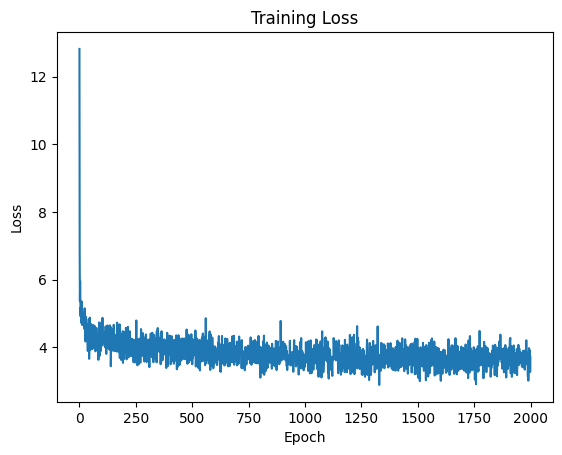

In [11]:
TRAIN_NEW_MODEL = True

if TRAIN_NEW_MODEL:
    model, training_loss = train(model, dataloader, mean_scale_tensor, var_scale_tensor, save=False)
    
    plt.plot(training_loss)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.show()
    plt.close()

In [12]:
def reverse_diffuse(model, beta, alpha, alpha_bar, T, samples=100, start=T, stop=1, X_T=None):
    model = model.to(device)
    beta = beta.to(device)
    alpha = alpha.to(device)
    alpha_bar = alpha_bar.to(device)

    model.eval()
    
    if X_T is None:
        X_T = torch.randn((samples, 2), device=device)
    else:
        samples = X_T.shape[0]

    X_t = X_T
    X_t = X_t.to(device)

    with torch.no_grad():
        for t in reversed(range(stop, start+1)):
            if t == 1:
                t_model = torch.ones(samples, device=device) * t
                t_model = (t_model.float() / T).unsqueeze(-1)
                X_model = torch.cat([X_t, t_model], dim=-1)
                epsilon_hat = model(X_model)
                mu_t = (1./torch.sqrt(alpha[t-1])) * (X_t - (beta[t-1]/torch.sqrt(1-alpha_bar[t-1]))*epsilon_hat)
                X_t = mu_t
            else:
                t_model = torch.ones(samples, device=device) * t
                t_model = (t_model.float() / T).unsqueeze(-1)
                X_model = torch.cat([X_t, t_model], dim=-1)
                epsilon_hat = model(X_model)
                epsilon = torch.randn((samples, 2), device=device)
                mu_t = (1./torch.sqrt(alpha[t-1])) * (X_t - (beta[t-1]/torch.sqrt(1-alpha_bar[t-1]))*epsilon_hat)
                beta_t = (1-alpha_bar[t-2]) / (1-alpha_bar[t-1]) * beta[t-1]
                X_t = mu_t + torch.sqrt(beta_t) * epsilon
    return X_t

In [13]:
model = DiffusionModel()
model.load_state_dict(torch.load("./Models/Spiral_Model.pth", weights_only=True))

beta_tensor = torch.from_numpy(beta).float()
alpha_tensor = torch.from_numpy(alpha).float()
alpha_bar_tensor = torch.from_numpy(alpha_bar).float()

X_rev = reverse_diffuse(model, beta_tensor, alpha_tensor, alpha_bar_tensor, T, samples=1000).cpu().numpy()

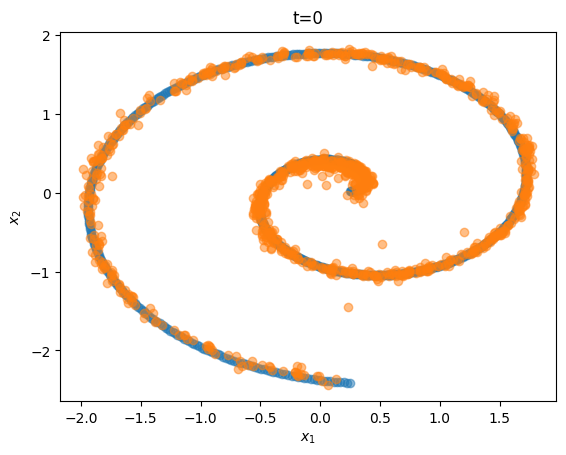

In [14]:
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.scatter(X_rev[:, 0], X_rev[:, 1], alpha=0.5)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('t='+str(T-T))
plt.show()
plt.close()

In [ ]:
spacing = 10

fig, ax = plt.subplots()

scat = ax.scatter(X[:, 0], X[:, 1], alpha=0.5)
max_edge = np.ceil(np.max(np.abs(X_t)))+1
ax.set(xlim=[-max_edge, max_edge], ylim=[-max_edge, max_edge])

def update(frame):
    global max_edge
    global X_t
    
    if frame*spacing <= T:
        forward = True
    else:
        forward = False
        t_prev = T - (spacing * (frame - (int(T/spacing)+1)))
        t = t_prev - spacing
    
    if frame==0:
        scat.set_offsets(X)
        X_t = X
        t=0
    else:
        if forward:
            for i in range(spacing):
                t = ((frame*spacing)-spacing) + i + 1
                X_t = diffusion_step(X_t, t, beta)
            scat.set_offsets(X_t)
        else:
            X_t = torch.from_numpy(X_t).float()
            X_t = reverse_diffuse(model, beta_tensor, alpha_tensor, alpha_bar_tensor, T, start=t_prev, stop=t+1, X_T=X_t).cpu().numpy()
            scat.set_offsets(X_t)
            scat.set_facecolor('#ff7f0e')

    edge = np.ceil(np.max(np.abs(X_t)))+1
    if max_edge < edge:
        max_edge = edge
        ax.set(xlim=[-max_edge, max_edge], ylim=[-max_edge, max_edge])
        
    ax.set_title('t='+ str(t))

    return scat

ani = animation.FuncAnimation(fig=fig, func=update, frames=(2*int(T/spacing))+1, interval=30)

plt.close()
HTML(ani.to_jshtml())

In [16]:
def get_field_model(model, t, X_grid, Y_grid):
    model = model.to(device)
    model.eval()
    
    grid_model = np.vstack([X_grid.flatten(), Y_grid.flatten()]).T
    grid_model = torch.from_numpy(grid_model).float()
    grid_model = grid_model.to(device)
    
    t_model = torch.ones(grid_model.shape[0], device=device) * t
    t_model = (t_model.float() / T).unsqueeze(-1)
    
    model_input = torch.cat([grid_model, t_model], dim=-1)
    
    with torch.no_grad():
        field_model = model(model_input)
        field = field_model.cpu().numpy()
        U = field.T[0].reshape(X_grid.shape)
        V = field.T[1].reshape(Y_grid.shape)
    return U, V

In [ ]:
spacing = 10

points_per_axis = 30
xy_lim = 2

x = np.linspace(-xy_lim, xy_lim, points_per_axis)
y = np.linspace(-xy_lim, xy_lim, points_per_axis)
X_grid, Y_grid = np.meshgrid(x, y)

model = DiffusionModel()
model.load_state_dict(torch.load("./Models/Spiral_Model.pth", weights_only=True))

fig, ax = plt.subplots()

U, V = get_field_model(model, T, X_grid, Y_grid)
quiv = ax.quiver(X_grid, Y_grid, U, V)

def update(frame):
    t = T - (frame*spacing)
    if t == 0:
        U, V = get_field_model(model, 1, X_grid, Y_grid)
        quiv.set_UVC(U, V)
        ax.set_title("Predicted Forward Noise to Reach $x_t$ \n t=1")
    else:
        U, V = get_field_model(model, t, X_grid, Y_grid)
        quiv.set_UVC(U, V)
        ax.set_title("Predicted Forward Noise to Reach $x_t$ \n t=" + str(t))
    return quiv

ani = animation.FuncAnimation(fig=fig, func=update, frames=int(T/spacing)+1, interval=30)
        
plt.close()
HTML(ani.to_jshtml())